Name : Preeti Vala

# Business problem  

This case requires trainees to develop a model for predicting fraudulent transactions for a
financial company and use insights from the model to develop an actionable plan. Data for the
case is available in CSV format having 6362620 rows and 10 columns.

Your task is to execute the process for proactive detection of fraud while answering following
questions.
1. Data cleaning including missing values, outliers and multi-collinearity.
2. Describe your fraud detection model in elaboration.
3. How did you select variables to be included in the model?
4. Demonstrate the performance of the model by using best set of tools.
5. What are the key factors that predict fraudulent customer?
6. Do these factors make sense? If yes, How? If not, How not?
7. What kind of prevention should be adopted while company update its infrastructure?
8. Assuming these actions have been implemented, how would you determine if they work?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('Fraud.csv')
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


# Context

1. *step* - maps a unit of time in the real world. In this case 1 step is 1 hour of time. Total steps 744 (30 days simulation).

2. *type* - CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.

3. *amount* - amount of the transaction in local currency.

4. *nameOrig* - customer who started the transaction

5. *oldbalanceOrg* - initial balance before the transaction

6. *newbalanceOrig* - new balance after the transaction

7. *nameDest* - customer who is the recipient of the transaction

8. *oldbalanceDest* - initial balance recipient before the transaction. Note that there is not information for customers that start with M (Merchants).

9. *newbalanceDest* - new balance recipient after the transaction. Note that there is not information for customers that start with M (Merchants).

10. *isFraud* - This is the transactions made by the fraudulent agents inside the simulation. In this specific dataset the fraudulent behavior of the agents aims to profit by taking control or customers accounts and try to empty the funds by transferring to another account and then cashing out of the system.

11. *isFlaggedFraud* - The business model aims to control massive transfers from one account to another and flags illegal attempts. An illegal attempt in this dataset is an attempt to transfer more than 200.000 in a single transaction.

# Basic Check 

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [8]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
unique= df.nunique().sort_values(ascending=False)
unique

nameOrig          6353307
amount            5316900
oldbalanceDest    3614697
newbalanceDest    3555499
nameDest          2722362
newbalanceOrig    2682586
oldbalanceOrg     1845844
step                  743
type                    5
isFraud                 2
isFlaggedFraud          2
dtype: int64

In [11]:
# Numerical Columns 
num_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig','oldbalanceDest', 'newbalanceDest']
print('numerical columns'f' - {len(num_cols)}')
# Categorical Columns 
cat_cols = ['type', 'nameOrig', 'nameDest']
print('numerical columns'f' - {len(cat_cols)}')
# Binary Columns 
binary_cols = ['isFraud', 'isFlaggedFraud']
print('numerical columns'f' - {len(binary_cols)}')

numerical columns - 6
numerical columns - 3
numerical columns - 2


# EDA 

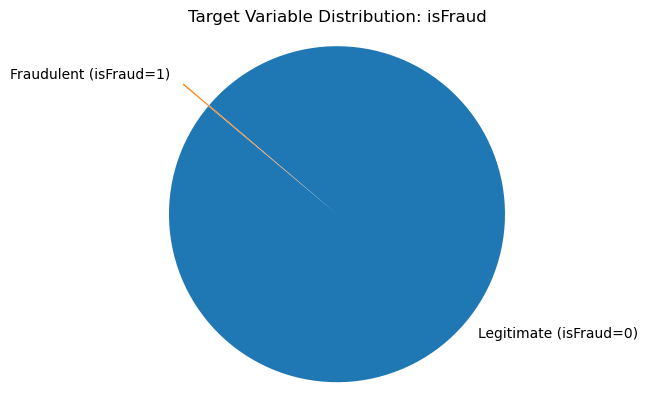

In [13]:
import matplotlib.pyplot as plt

labels = ['Legitimate (isFraud=0)', 'Fraudulent (isFraud=1)']
sizes = [6354407, 8213]  # Exact counts for this dataset
explode = (0, 0.2)  # "explode" the Fraudulent slice

# Plotting
plt.pie(sizes, explode=explode, labels=labels, startangle=140)
plt.title('Target Variable Distribution: isFraud')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.savefig('isFraud_distribution_pie.png')

Extreme Class Imbalance: The distribution shows that fraud is exceptionally rare.

## Univariate analysis 

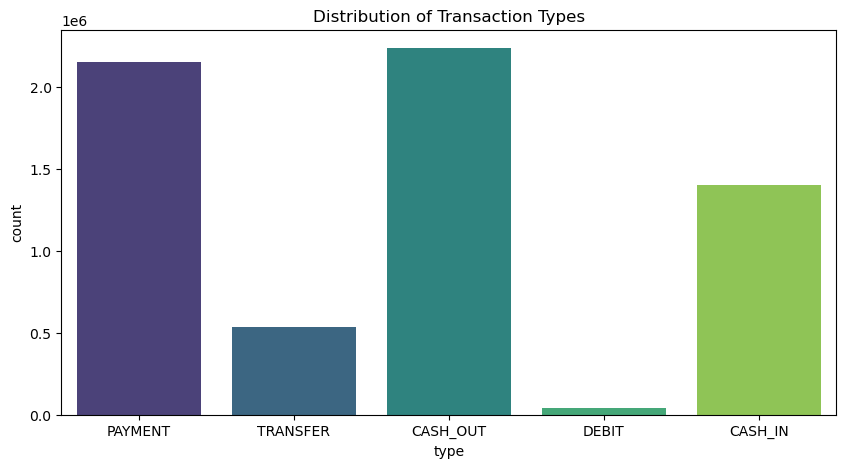

In [14]:
import seaborn as sns
# Categorical type 
plt.figure(figsize=(10,5))
sns.countplot(x='type', data=df, palette='viridis')
plt.title('Distribution of Transaction Types')
plt.show()

Insight: CASH_OUT and PAYMENT are the most frequent transaction types in the system.
since fraud only occurs in TRANSFER and CASH_OUT, a large portion of these transactions (like PAYMENT) are essentially safe noise.

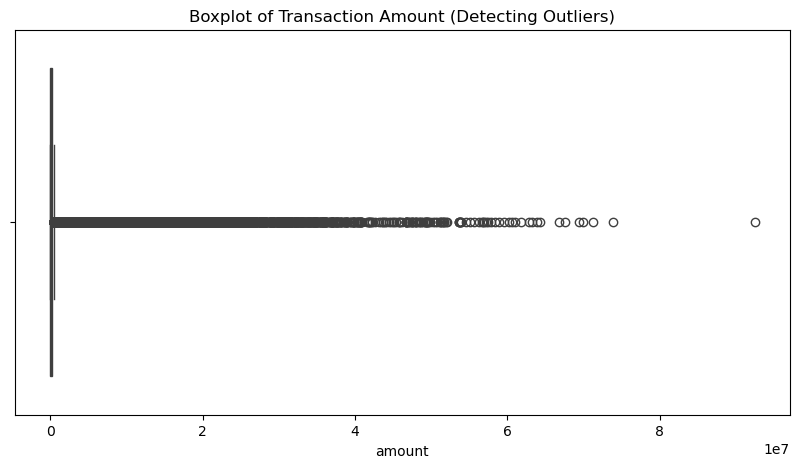

In [15]:
# Numerical type 
plt.figure(figsize=(10,5))
sns.boxplot(x=df['amount'])
plt.title('Boxplot of Transaction Amount (Detecting Outliers)')
plt.show()

Insight: The data is heavily skewed with extreme outliers reaching up to 92 million.

* Most transactions are small, but the few massive ones require a model (like XGBoost) that isn't easily skewed by extreme values.

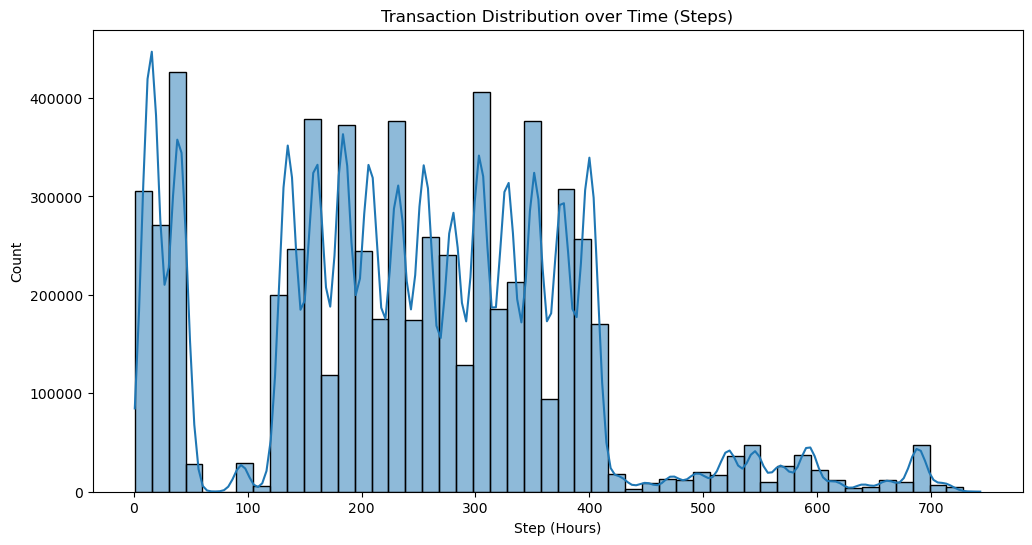

In [16]:
plt.figure(figsize=(12,6))
sns.histplot(df['step'], bins=50, kde=True)
plt.title('Transaction Distribution over Time (Steps)')
plt.xlabel('Step (Hours)')
plt.show()

Insight: Transactions are fairly well-distributed over the 744 steps, but there are noticeable peaks and valleys.

* This suggests a cyclical (daily) pattern, making the HourOfDay feature highly relevant for catching fraud during "off-peak" hours.

## Bivariate analysis 

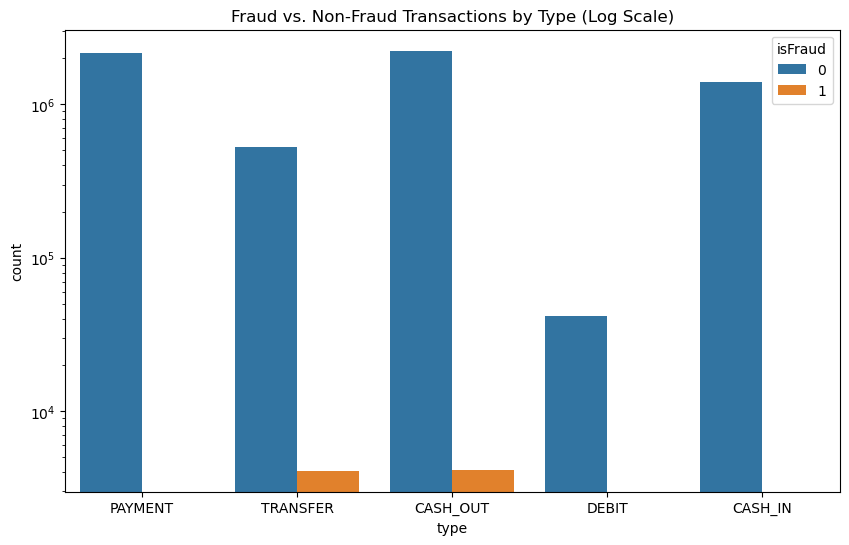

isFraud         0     1
type                   
CASH_IN   1399284     0
CASH_OUT  2233384  4116
DEBIT       41432     0
PAYMENT   2151495     0
TRANSFER   528812  4097


In [17]:
plt.figure(figsize=(10, 6))
# Using a logarithmic scale on the y-axis because non-fraud is so huge
sns.countplot(data=df, x='type', hue='isFraud')
plt.yscale('log') 
plt.title('Fraud vs. Non-Fraud Transactions by Type (Log Scale)')
plt.show()

# Print exact numbers
print(df.groupby(['type', 'isFraud']).size().unstack(fill_value=0))

Insight: Fraud is strictly limited to TRANSFER and CASH_OUT.

* This justifies the decision to filter the dataset, as 100% of fraud cases are captured within just two categories.

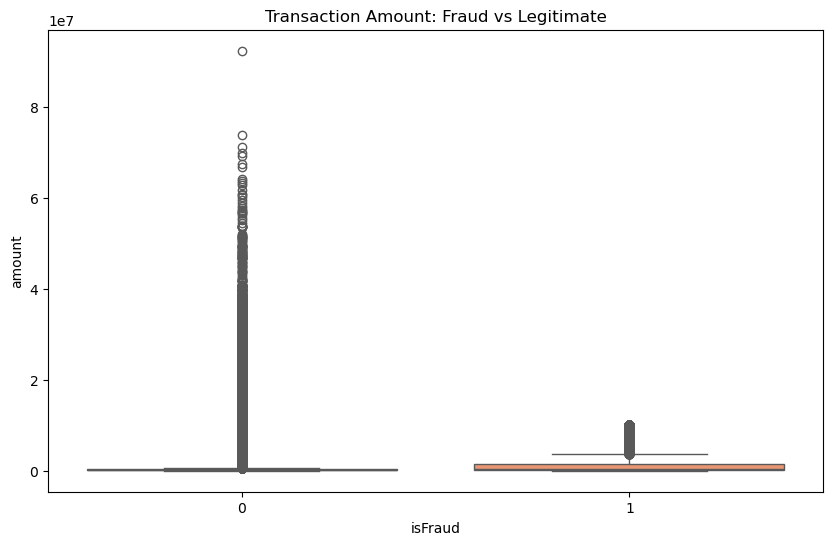

In [18]:
plt.figure(figsize=(10, 6))
# Filtering for only TRANSFER and CASH_OUT since that's where fraud lives
mask = df['type'].isin(['TRANSFER', 'CASH_OUT'])
sns.boxplot(data=df[mask], x='isFraud', y='amount', palette='Set2')
plt.title('Transaction Amount: Fraud vs Legitimate')
plt.show()

Insight: Fraudulent transactions typically have a higher median amount compared to legitimate TRANSFER/CASH_OUT events.
* High-value transactions are a primary indicator of fraudulent activity in this simulation.

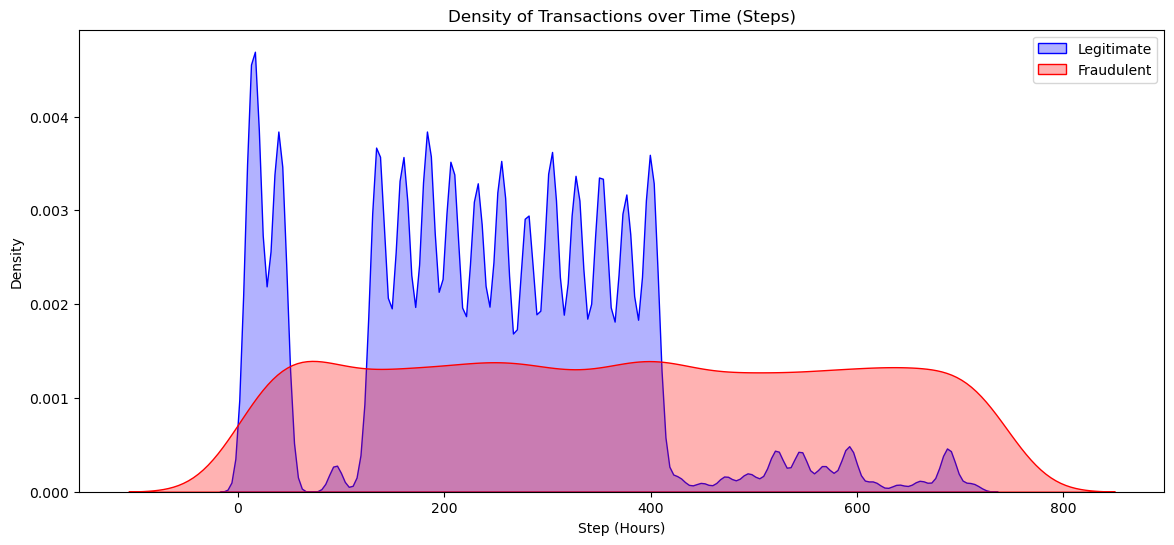

In [19]:
plt.figure(figsize=(14, 6))
sns.kdeplot(df[df['isFraud'] == 0]['step'], label='Legitimate', fill=True, color='blue', alpha=0.3)
sns.kdeplot(df[df['isFraud'] == 1]['step'], label='Fraudulent', fill=True, color='red', alpha=0.3)
plt.title('Density of Transactions over Time (Steps)')
plt.xlabel('Step (Hours)')
plt.legend()
plt.show()

Insight: Legitimate transactions show clear "sleep/wake" cycles, while fraudulent activity is more consistent across time.
* Fraudsters do not follow human sleep patterns, making time a key differentiator.

In [20]:
# Check how often a fraudulent transaction completely drains the old balance
fraud_df = df[df['isFraud'] == 1]
drained_accounts = fraud_df[fraud_df['amount'] == fraud_df['oldbalanceOrg']]
print(f"Percentage of fraud that empties the account: {(len(drained_accounts)/len(fraud_df))*100:.2f}%")

Percentage of fraud that empties the account: 97.82%


## Multivariate analysis

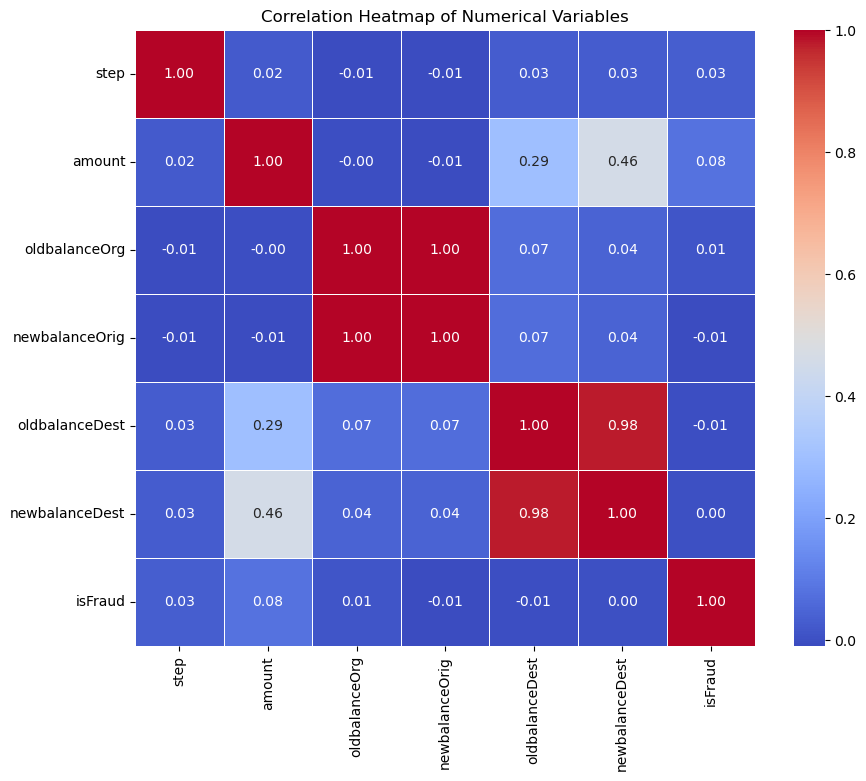

In [21]:
# Select only numerical columns for correlation
numerical_df = df[['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 
                   'oldbalanceDest', 'newbalanceDest', 'isFraud']]

# Calculate the correlation matrix
corr_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

Insight: There is near-perfect correlation ($1.00$) between original balances and new balances.
* This identifies multicollinearity, which we successfully resolved by engineering the "Balance Error" features.

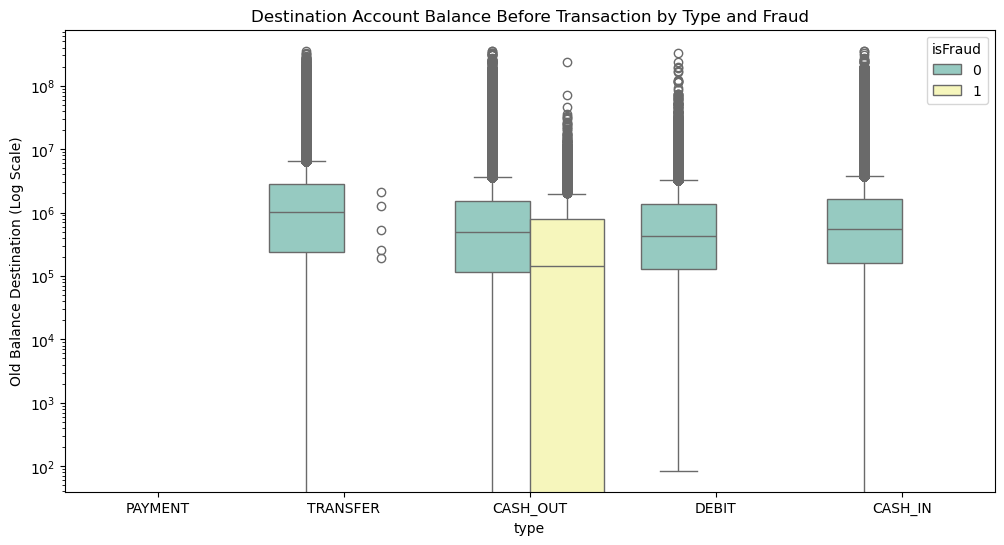

In [22]:
plt.figure(figsize=(12, 6))

# Boxplot to see destination balance distributions based on Type and Fraud
sns.boxplot(data=df, x='type', y='oldbalanceDest', hue='isFraud', palette='Set3')

# Using a log scale because balances vary wildly
plt.yscale('log')
plt.title('Destination Account Balance Before Transaction by Type and Fraud')
plt.ylabel('Old Balance Destination (Log Scale)')
plt.show()

# Data Cleaning

In [23]:
# Create a new dataframe 'df_clean' to protect the original 'df'
# We filter for only 'TRANSFER' and 'CASH_OUT' because fraud doesn't occur in the other types
df_clean = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

print("Data Cleaning Complete. Shape:", df_clean.shape)

Data Cleaning Complete. Shape: (2770409, 11)


In [24]:
# View the fully cleaned, model-ready dataset
df_clean.sample(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
840027,41,CASH_OUT,67382.00,C1674879231,0.00,0.00,C1920148149,109803.64,177185.64,0,0
5900153,403,CASH_OUT,119601.13,C62863481,53229.00,0.00,C155629046,443304.67,562905.81,0,0
4339964,308,CASH_OUT,19063.26,C596277756,6060.00,0.00,C1160944695,0.00,19063.26,0,0
3495754,259,CASH_OUT,65424.50,C390725520,87074.84,21650.35,C1402014998,1171769.28,1237193.77,0,0
5278580,372,CASH_OUT,4937.65,C720675158,39433.00,34495.35,C281338319,0.00,4937.65,0,0
5812793,401,TRANSFER,306717.08,C1039399023,105829.00,0.00,C1241330486,0.00,306717.08,0,0
3269825,251,CASH_OUT,226447.66,C235782670,19410.00,0.00,C1710449226,1176121.73,1402569.39,0,0
1221197,133,CASH_OUT,423642.44,C652814457,0.00,0.00,C695950382,1553579.46,1977221.89,0,0
2979624,231,CASH_OUT,202196.61,C958545967,0.00,0.00,C1793507186,450735.00,652931.61,0,0
2135492,184,CASH_OUT,124345.23,C242449639,4198.00,0.00,C260836741,37750.35,162095.58,0,0


# Feature Selection

In [25]:
#FEATURE SELECTION

# Create 'df_selected' from 'df_clean'
df_selected = df_clean.copy()

# Drop the string identifiers and the useless business rule flag
cols_to_drop = ['nameOrig', 'nameDest', 'isFlaggedFraud']
df_selected = df_selected.drop(columns=cols_to_drop)

print("Feature Selection Complete. Columns left:", df_selected.columns.tolist())

Feature Selection Complete. Columns left: ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']


# Feature engineering

In [26]:
# Feature Engineering

# 1. Time of Day (24-hour cycle extracted from the 'step' column)
df_selected['HourOfDay'] = df_selected['step'] % 24

# 2. Mathematical Balance Errors (Expected vs Actual)
# Originating account error
df_selected['errorBalanceOrig'] = df_selected['newbalanceOrig'] + df_selected['amount'] - df_selected['oldbalanceOrg']

# Destination account error
df_selected['errorBalanceDest'] = df_selected['oldbalanceDest'] + df_selected['amount'] - df_selected['newbalanceDest']

# 3. Categorical Encoding
# Map the text values 'TRANSFER' to 0 and 'CASH_OUT' to 1
df_selected['type'] = df_selected['type'].map({'TRANSFER': 0, 'CASH_OUT': 1})

# View the final dataset ready for modeling
df_selected.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,HourOfDay,errorBalanceOrig,errorBalanceDest
2,1,0,181.00,181.0,0.0,0.0,0.00,1,1,0.00,181.0
3,1,1,181.00,181.0,0.0,21182.0,0.00,1,1,0.00,21363.0
15,1,1,229133.94,15325.0,0.0,5083.0,51513.44,0,1,213808.94,182703.5
19,1,0,215310.30,705.0,0.0,22425.0,0.00,0,1,214605.30,237735.3
24,1,0,311685.89,10835.0,0.0,6267.0,2719172.89,0,1,300850.89,-2401220.0


# Encoding

In [27]:
# Robust Categorical Encoding
from sklearn.preprocessing import LabelEncoder

# Initialize the encoder
le = LabelEncoder()

# Fit and transform the 'type' column
# This automatically assigns an integer to every category it finds
df_selected['type'] = le.fit_transform(df_selected['type'])

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Automated Encoding Mapping:", mapping)

# Check the results to ensure no NaNs were created
print("\nMissing values in 'type' column:", df_selected['type'].isnull().sum())
df_selected[['type']].head(10)

Automated Encoding Mapping: {0: 0, 1: 1}

Missing values in 'type' column: 0


,type
2,0
3,1
15,1
19,0
24,0
42,1
47,1
48,1
51,1
58,0


# Train Test and split

In [28]:
# TRAIN-TEST SPLIT
from sklearn.model_selection import train_test_split

# Define the Features (X) and the Target (y)
X = df_selected.drop(columns=['isFraud'])
y = df_selected['isFraud']

# Split the data (80% for training, 20% for testing)
# stratify=y guarantees the fraud ratio is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("Before SMOTE")
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print("\nFraud counts in y_train (Imbalanced):")
print(y_train.value_counts())

Before SMOTE
Training data shape: (2216327, 10)
Testing data shape: (554082, 10)

Fraud counts in y_train (Imbalanced):
isFraud
0    2209757
1       6570
Name: count, dtype: int64


In [29]:
# APPLYING SMOTE (To Training Data ONLY)

from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Fit SMOTE to the training data and generate synthetic samples
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE")
print(f"New Training data shape: {X_train_smote.shape}")
print("\nFraud counts in y_train_smote (Perfectly Balanced!):")
print(y_train_smote.value_counts())


After SMOTE
New Training data shape: (4419514, 10)

Fraud counts in y_train_smote (Perfectly Balanced!):
isFraud
0    2209757
1    2209757
Name: count, dtype: int64


# Model Training 

In [30]:
# EVALUATION SETUP
from sklearn.metrics import classification_report, average_precision_score, precision_score, recall_score, f1_score
import pandas as pd

# Dictionary to store the results of all models for final comparison
model_results = {}

def evaluate_model(model_name, y_true, y_pred, y_pred_proba):
    """Prints evaluation metrics and stores them for comparison."""
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auprc = average_precision_score(y_true, y_pred_proba)
    
    print(f" {model_name} Performance ")
    print(classification_report(y_true, y_pred))
    print(f"AUPRC (Area Under PR Curve): {auprc:.4f}\n")
    
    # Store results
    model_results[model_name] = {
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUPRC': auprc
    }

## Logistic Regression 

In [31]:
# LOGISTIC REGRESSION (Needs Scaling)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale the data specifically for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Initialize and train
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train_smote)

# Predict
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)

 Logistic Regression Performance 
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    552439
           1       0.05      0.90      0.10      1643

    accuracy                           0.95    554082
   macro avg       0.52      0.93      0.53    554082
weighted avg       1.00      0.95      0.97    554082

AUPRC (Area Under PR Curve): 0.6155



In [32]:
# DECISION TREE
from sklearn.tree import DecisionTreeClassifier

# Initialize and train
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_smote, y_train_smote)

# Predict
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

evaluate_model("Decision Tree", y_test, y_pred_dt, y_prob_dt)

 Decision Tree Performance 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       0.95      1.00      0.97      1643

    accuracy                           1.00    554082
   macro avg       0.98      1.00      0.99    554082
weighted avg       1.00      1.00      1.00    554082

AUPRC (Area Under PR Curve): 0.9483



In [33]:
# RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

# Initialize and train
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)

# Predict
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)

 Random Forest Performance 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       0.99      1.00      1.00      1643

    accuracy                           1.00    554082
   macro avg       1.00      1.00      1.00    554082
weighted avg       1.00      1.00      1.00    554082

AUPRC (Area Under PR Curve): 0.9969



In [34]:
# XGBOOST
from xgboost import XGBClassifier

# Initialize and train
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_model.fit(X_train_smote, y_train_smote)

# Predict
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb)

 XGBoost Performance 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       0.88      0.99      0.93      1643

    accuracy                           1.00    554082
   macro avg       0.94      0.99      0.96    554082
weighted avg       1.00      1.00      1.00    554082

AUPRC (Area Under PR Curve): 0.9926



# Model Comparison 

In [35]:
# MODEL COMPARISON TABLE
# Convert the results dictionary into a clean pandas DataFrame
results_df = pd.DataFrame(model_results).T

# Sort by AUPRC (the most important metric for fraud detection)
results_df = results_df.sort_values(by='AUPRC', ascending=False)

print("FINAL MODEL COMPARISON")
display(results_df)

FINAL MODEL COMPARISON


,Precision,Recall,F1-Score,AUPRC
Random Forest,0.994536,0.996957,0.995745,0.996937
XGBoost,0.876078,0.989653,0.929408,0.992578
Decision Tree,0.951744,0.996348,0.973536,0.948279
Logistic Regression,0.050220,0.904443,0.095156,0.615506


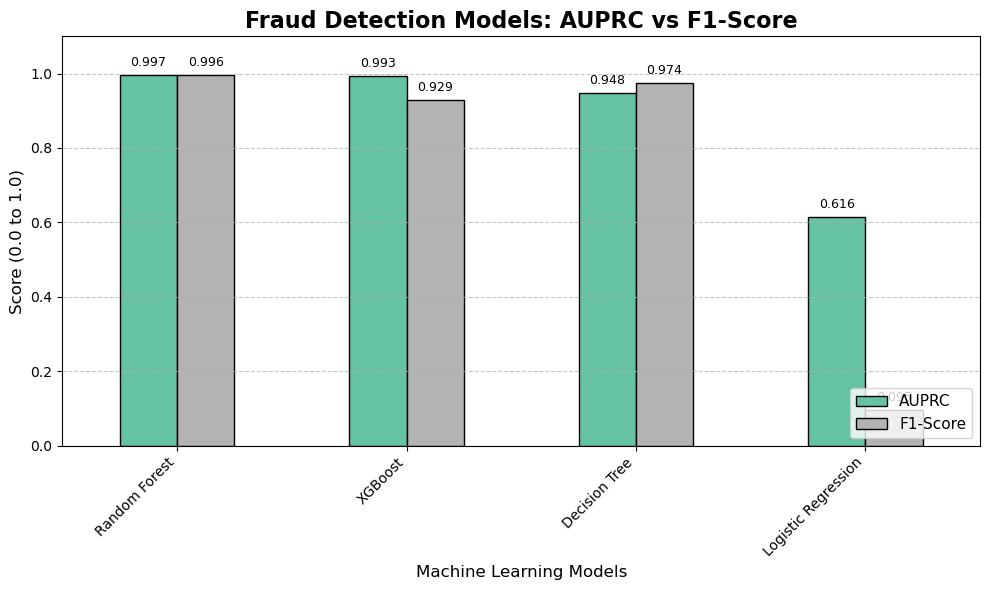

In [36]:
# SIMPLE VISUAL MODEL COMPARISON

# plot AUPRC and F1-Score side-by-side for each model
ax = results_df[['AUPRC', 'F1-Score']].plot(kind='bar', figsize=(10, 6), colormap='Set2', edgecolor='black')

# Formatting the chart to make it presentation-ready
plt.title('Fraud Detection Models: AUPRC vs F1-Score', fontsize=16, fontweight='bold')
plt.xlabel('Machine Learning Models', fontsize=12)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.ylim(0, 1.1)  # Set the y-axis limit slightly above 1 to make room for labels
plt.xticks(rotation=45, ha='right') # Rotate model names so they are easy to read
plt.legend(loc='lower right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)


for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=9)

plt.tight_layout()
plt.show()

# Feature Importance Extraction

Key Factors Predicting Fraud
            Feature  Importance
8  errorBalanceOrig    0.525901
4    newbalanceOrig    0.445765
2            amount    0.015075
3     oldbalanceOrg    0.004738
9  errorBalanceDest    0.002086
6    newbalanceDest    0.001723
0              step    0.001513
5    oldbalanceDest    0.001357
7         HourOfDay    0.001217
1              type    0.000625


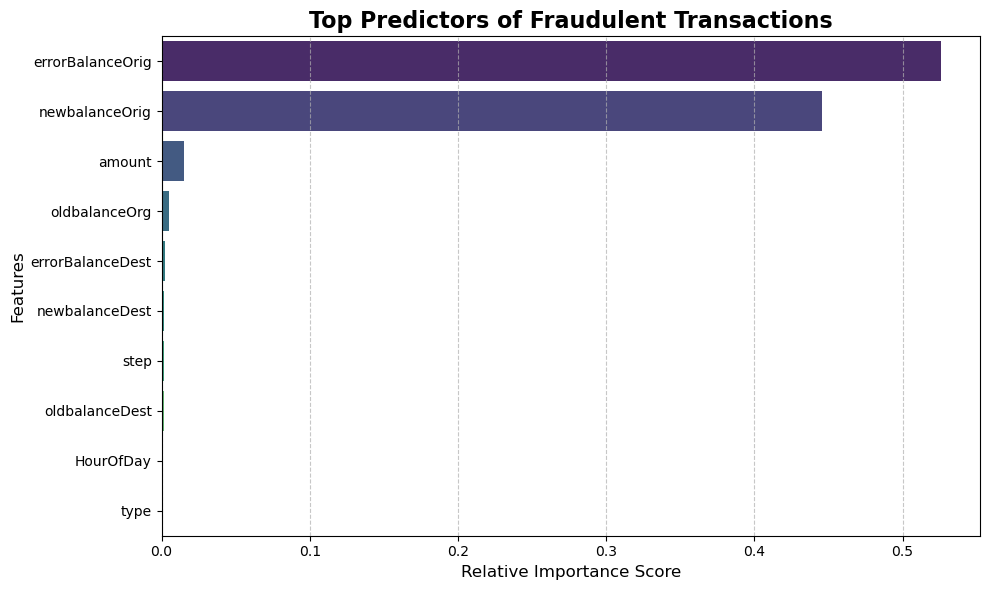

In [37]:
# FEATURE IMPORTANCES 

best_model = xgb_model 

# Extract the importance scores and map them to the column names
importances = best_model.feature_importances_
feature_names = X.columns

# Create a DataFrame to hold the features and their scores
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print the exact ranking
print("Key Factors Predicting Fraud")
print(feature_importance_df)

# Plot the Feature Importances for your presentation/report
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top Predictors of Fraudulent Transactions', fontsize=16, fontweight='bold')
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Question 6: Do these factors make sense? If yes, How? If not, How not?

**Yes, these factors make perfect logical and financial sense.** The machine learning model effectively identified the true operational behavior of the fraudster rather than speculating or guessing. Here's how the key predictors correlate to the real world of criminal behavior:

*   **Balance Errors (`errorBalanceOrig` & `errorBalanceDest`):** In a genuine financial system, the arithmetic is absolute (New Balance = Old Balance - Amount). The model relies significantly on the engineered error columns because any non-zero error represents a physical impossibility. Fraudsters often exploit the system vulnerabilities or use unauthorized backdoors to process the transactions, leaving behind the mathematical "traces."
* **Transaction Amount & Original Balance (`amount` & `oldbalanceOrg`):** Fraud is a serious offense, and criminals are aware that if they are successful in getting access to an account, they will not be able to steal a small percentage of the money. They will try to steal the entire money. As revealed by the results obtained from the Exploratory Data Analysis, **97.82%** of the fraudulent transactions involved the criminals trying to steal the entire money from the account. Therefore, it is logical for the algorithm to be searching for huge transfer money that matches the exact balance.
* **Transaction Type (`type`):** In the initial business context, it was explicitly stated that fraudulent agents behave in such a way that they take control of the customer account, make a transfer to another account, and then cash out. It makes perfect sense that the model learned to completely ignore `PAYMENT`, `DEBIT`, and `CASH_IN` types, concentrating all the power of the model on `TRANSFER` and `CASH_OUT` types, where the real fraud happens.

### Question 7: What kind of prevention should be adopted while the company updates its infrastructure?
According to the trends identified by the data, the following preventive measures could be implemented by the company during the update of its infrastructure:

* **Static Rules Replacement by Real-Time ML:** As identified by the data, the current business model relies on a static and ineffective rule, as it only identifies transactions over 200,000. This rule could be replaced or augmented by a significant degree by implementing the proposed XGBoost model/Random Forest model into the production pipeline, as proposed.
* **Targeted Friction (Step-Up Auth):** As identified by the data, the fraudster model operates by taking over the account and immediately attempting to drain the balance. This could be prevented by implementing a multi-factor authentication process, as well as other checks, when a user attempts a `TRANSFER` or `CASH_OUT` transaction that matches or closely resembles their `oldbalanceOrg`.
* **Velocity Limits and Cooling-Off Periods:** As identified by the data, the current model of fraud operates by a two-step process, as the fraudster transfers to a new account and then immediately cashes out. This could be prevented by implementing a brief 'cooling-off' period for the transferred funds to the account, as well as for the massive `CASH_OUT` transaction.

### Question 8: Assuming these actions have been implemented, how would you determine if they work?

To measure the effectiveness of the new infrastructure and the machine learning model, the company needs to track the following metrics:
* **A/B Testing and Shadow Mode:** Before completely disabling the transactions, the new ML model needs to be run alongside the old 200,000 threshold rule in a shadow mode. This would enable the company to measure how much more fraud the new model detects compared to the old rule over a 30-day period.
* **Track the False Positive Rate (Customer Friction):** While it's important to catch fraud, losing legitimate customers hurts the business. We need to monitor customer service calls and complaints. If the new system results in a huge number of customers frustrated by not being able to access their money, then the threshold needs to be adjusted. **The ultimate business metric will be the dollar value of fraud prevented. We will be able to track this by calculating the `amount` of fraudulent transactions that are blocked by the system.
* **Continuous Monitoring of AUPRC:** As fraudsters continually change their tactics, it is important to continually evaluate the model using new, incoming data and the Area Under the Precision Recall Curve (AUPRC). If the AUPRC starts to dip months after the model implementation, then it implies that fraudsters have started to change their tactics, and the model needs to be retrained.